In [1]:
# Let's evaluate a mixed portfolio of stocks and bonds with different weights.
# We will summarize its historical performance in terms of returns, volatility, and drawdown.
# This analysis aims to help investors identify the most suitable asset allocation
# based on their individual risk tolerance.

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

start_date='2005-01-01'
end_date='2025-01-01'
data_sp500= yf.download ('^GSPC', start_date, end_date)
data_bonds= yf.download("IEF", start_date,end_date)

data_sp500=data_sp500['Close'].dropna()
data_bonds=data_bonds['Close'].dropna()
sp500_returns= data_sp500.pct_change().dropna()
bonds_returns= data_bonds.pct_change().dropna()
print(sp500_returns.columns)


/var/folders/35/fpqmwycx1ln5c7s2lxkvbtg80000gp/T/ipykernel_1409/2232476509.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_sp500= yf.download ('^GSPC', start_date, end_date)
[*********************100%***********************]  1 of 1 completed
/var/folders/35/fpqmwycx1ln5c7s2lxkvbtg80000gp/T/ipykernel_1409/2232476509.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_bonds= yf.download("IEF", start_date,end_date)
[*********************100%***********************]  1 of 1 completed

Index(['^GSPC'], dtype='object', name='Ticker')


In [2]:
# We define the possible asset allocations starting from a 100% stocks portfolio.
# Then, step by step, we introduce bonds with increasing weights,
# until we reach the opposite extreme of a 100% bonds portfolio.

allocation=[]
for n in range (100,-1,-10):
  weight_stocks= n
  weight_bond= 100-n
  allocation.append(f"{weight_stocks}% Stocks / {weight_bond}% Bonds")

df= pd.DataFrame({"ASSET ALLOCATION": allocation})


In [3]:
#Let's procede with the CAGR calculation for all the portfolio we defined earlier. 
n_year= (pd.to_datetime(end_date)-pd.to_datetime(start_date)).days/365
cagr_sp500= (((data_sp500.iloc[-1]/data_sp500.iloc[0])**(1/n_year))-1)*100
cagr_bonds=(((data_bonds.iloc[-1]/data_bonds.iloc[0])**(1/n_year))-1)*100
CAGR=[]
for n2 in range(100,-1,-10):
  weight_stocks= n2/100
  weight_bond= (100-n2)/100
  calculation_return= (weight_stocks*float(cagr_sp500) + weight_bond*float(cagr_bonds))
  CAGR.append(round(calculation_return,2))
  
  
df['CAGR%']=CAGR

print(df)


          ASSET ALLOCATION  CAGR%
0   100% Stocks / 0% Bonds   8.26
1   90% Stocks / 10% Bonds   7.74
2   80% Stocks / 20% Bonds   7.22
3   70% Stocks / 30% Bonds   6.70
4   60% Stocks / 40% Bonds   6.18
5   50% Stocks / 50% Bonds   5.66
6   40% Stocks / 60% Bonds   5.14
7   30% Stocks / 70% Bonds   4.62
8   20% Stocks / 80% Bonds   4.10
9   10% Stocks / 90% Bonds   3.58
10  0% Stocks / 100% Bonds   3.06


/var/folders/35/fpqmwycx1ln5c7s2lxkvbtg80000gp/T/ipykernel_1409/2517966801.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  calculation_return= (weight_stocks*float(cagr_sp500) + weight_bond*float(cagr_bonds))


In [4]:
# as you can see in the previus table if you add bond in your portfolio you are 
#reducing your future return. The only idea to add some percentage of bonds is to
#reduce risk. So let's introduce historical volatility for the different asset allocations

sp500_returns= sp500_returns.squeeze()
bonds_returns=bonds_returns.squeeze()
vol=[]
for n3 in range (100,-1,-10):
 weight_stocks= n3/100
 weight_bonds= 1-weight_stocks
 new_returns= weight_stocks*sp500_returns+ weight_bonds*bonds_returns
 volatility=new_returns.std()*np.sqrt(252)
 vol.append(round(volatility,2)*100)

df['VOLATILITY %']=vol

print(df)



          ASSET ALLOCATION  CAGR%  VOLATILITY %
0   100% Stocks / 0% Bonds   8.26          19.0
1   90% Stocks / 10% Bonds   7.74          17.0
2   80% Stocks / 20% Bonds   7.22          15.0
3   70% Stocks / 30% Bonds   6.70          13.0
4   60% Stocks / 40% Bonds   6.18          11.0
5   50% Stocks / 50% Bonds   5.66           9.0
6   40% Stocks / 60% Bonds   5.14           7.0
7   30% Stocks / 70% Bonds   4.62           6.0
8   20% Stocks / 80% Bonds   4.10           6.0
9   10% Stocks / 90% Bonds   3.58           6.0
10  0% Stocks / 100% Bonds   3.06           7.0


In [5]:
# In the previous table, we see that adding bonds to the portfolio helps manage risk,
# but it also reduces the expected return. The most challenging question is:
# what is the optimal asset allocation for an investor to achieve their goals
# without taking on excessive risk?
# At this point, we introduce another useful measure: Expected Shortfall (ES)
#is the average loss in the worst cases beyond the Value at Risk (VaR). 
# We set a 95% level of confidence,so ES is the average loss in the worst 5% of scenarios.

alpha=0.95
zalpha=1.695
phi=(1/(np.sqrt(2*np.pi)))*(np.exp(-0.5*(zalpha*zalpha)))
cost=phi/(1-alpha)
ES=-(CAGR+np.array(vol)*cost)
df['EXPECTED SHORTFALL %']= ES
df['EXPECTED SHORTFALL %'] = df['EXPECTED SHORTFALL %'].round(2)
df.style.set_properties(**{'text-align': 'center'})
print(df)

          ASSET ALLOCATION  CAGR%  VOLATILITY %  EXPECTED SHORTFALL %
0   100% Stocks / 0% Bonds   8.26          19.0                -44.30
1   90% Stocks / 10% Bonds   7.74          17.0                -39.99
2   80% Stocks / 20% Bonds   7.22          15.0                -35.68
3   70% Stocks / 30% Bonds   6.70          13.0                -31.36
4   60% Stocks / 40% Bonds   6.18          11.0                -27.05
5   50% Stocks / 50% Bonds   5.66           9.0                -22.73
6   40% Stocks / 60% Bonds   5.14           7.0                -18.42
7   30% Stocks / 70% Bonds   4.62           6.0                -16.00
8   20% Stocks / 80% Bonds   4.10           6.0                -15.48
9   10% Stocks / 90% Bonds   3.58           6.0                -14.96
10  0% Stocks / 100% Bonds   3.06           7.0                -16.34


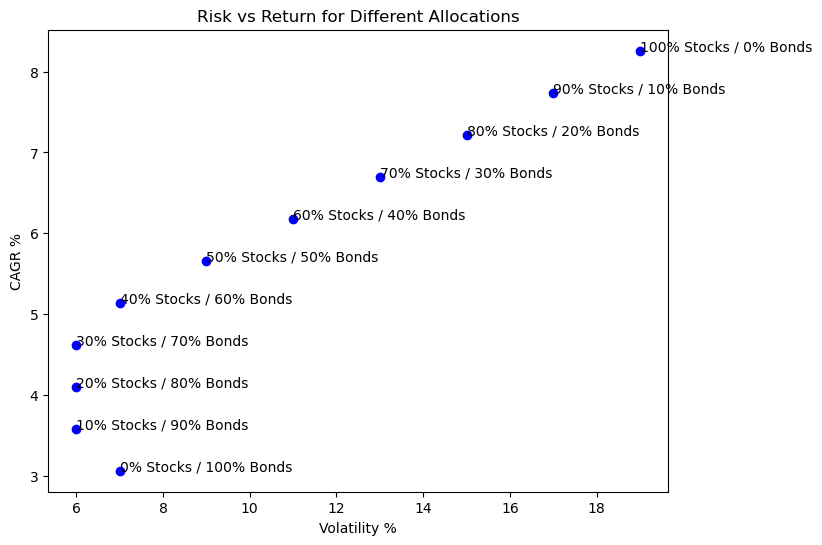

In [6]:
plt.figure(figsize=(8,6))
plt.scatter(df['VOLATILITY %'], df['CAGR%'], c='blue')
for i, txt in enumerate(df['ASSET ALLOCATION']):
    plt.annotate(txt, (df['VOLATILITY %'][i], df['CAGR%'][i]))
plt.xlabel('Volatility %')
plt.ylabel('CAGR %')
plt.title('Risk vs Return for Different Allocations')
plt.show()